In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")



file_path = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"

df = pd.read_csv(file_path)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [23]:
print("Shape:", df.shape)

df.info()

Shape: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [24]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [25]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [26]:
df = df.ffill()

In [27]:
print(df.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


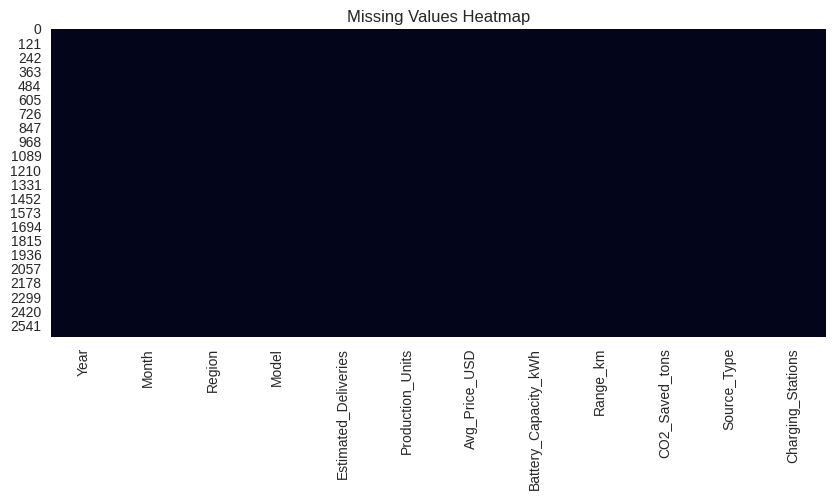

In [28]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

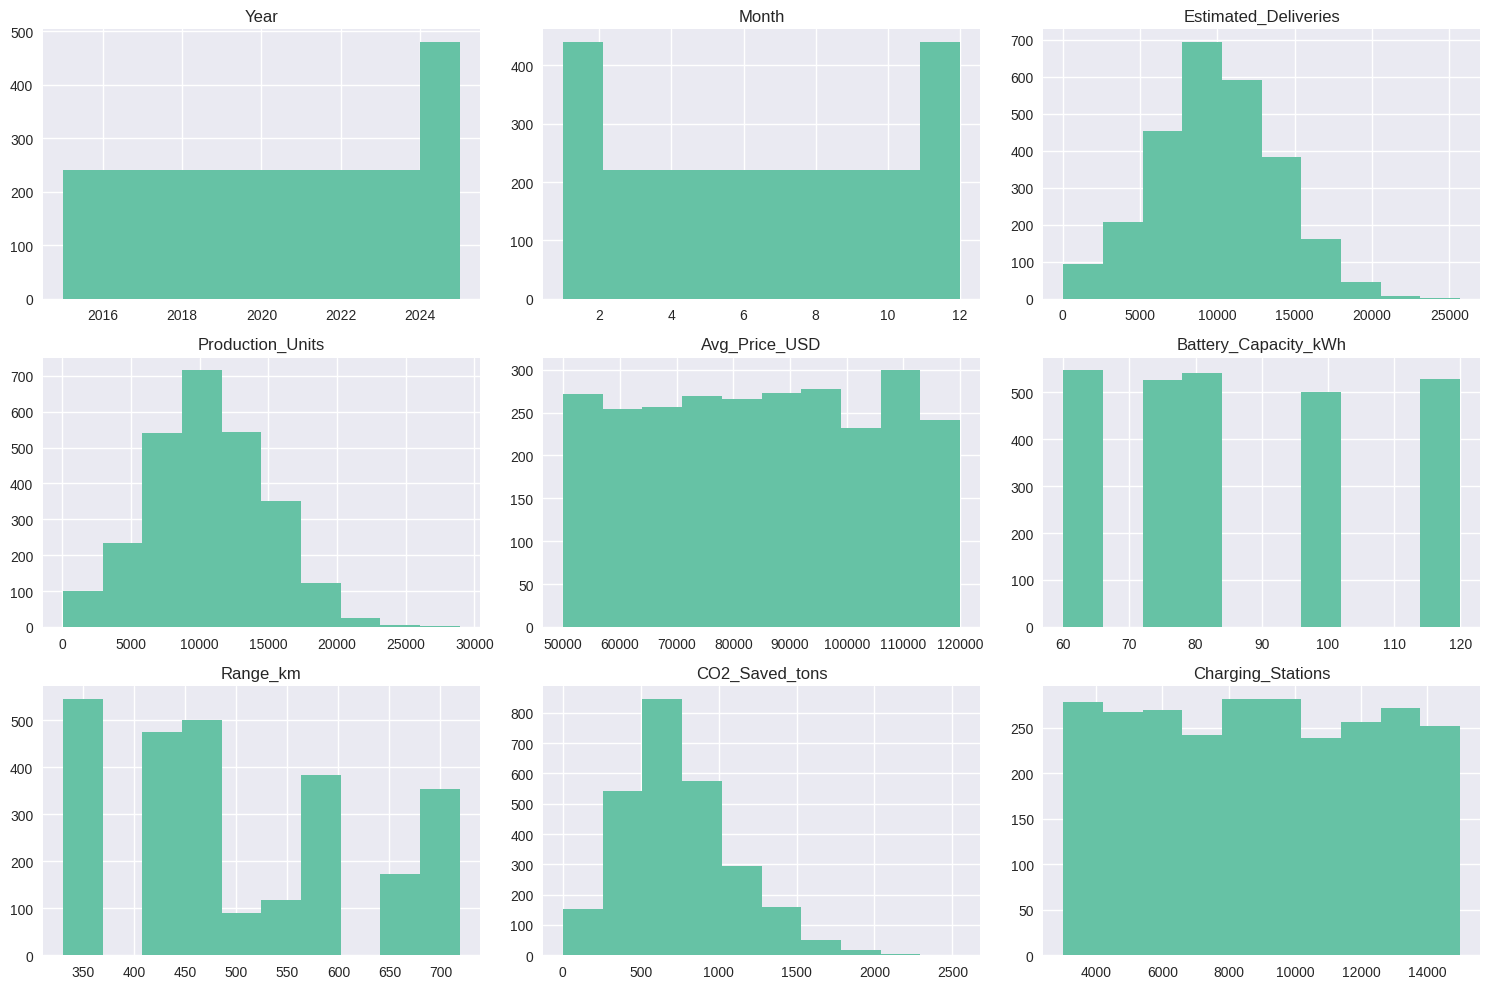

In [29]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

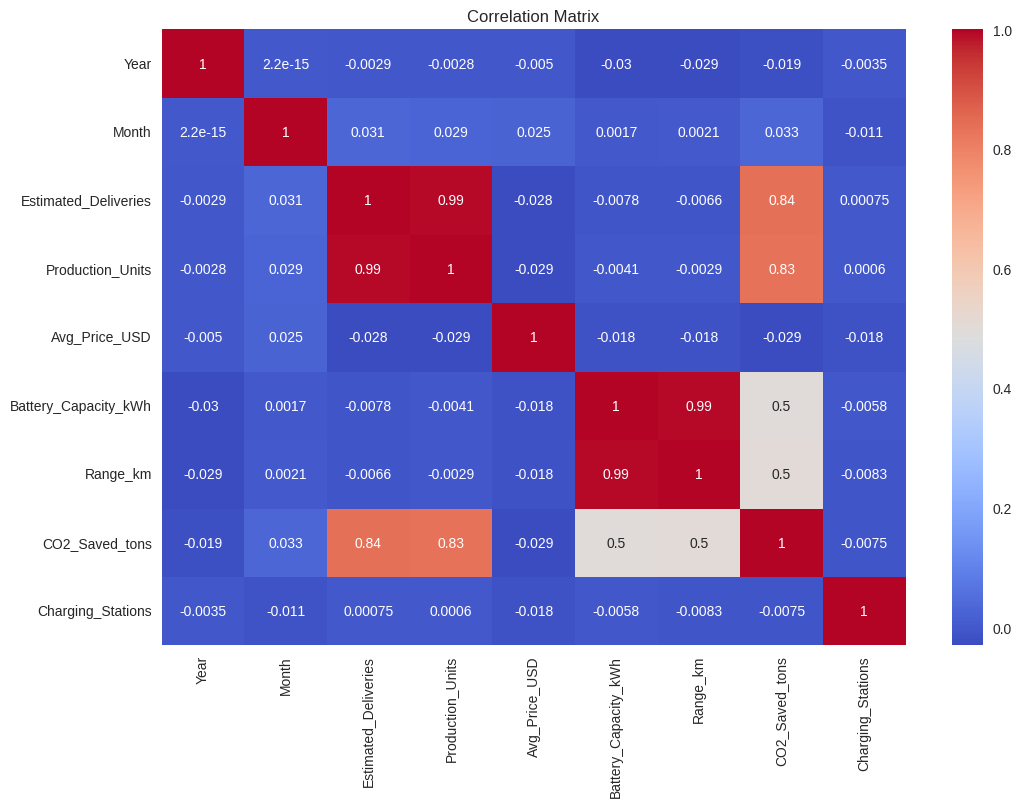

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [31]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

df = df.sort_values('Date')

df[['Date','Estimated_Deliveries']].head()

,Date,Estimated_Deliveries
872,2015-01-01,12446
2354,2015-01-01,11446
2312,2015-01-01,8803
2293,2015-01-01,6367
2215,2015-01-01,8795


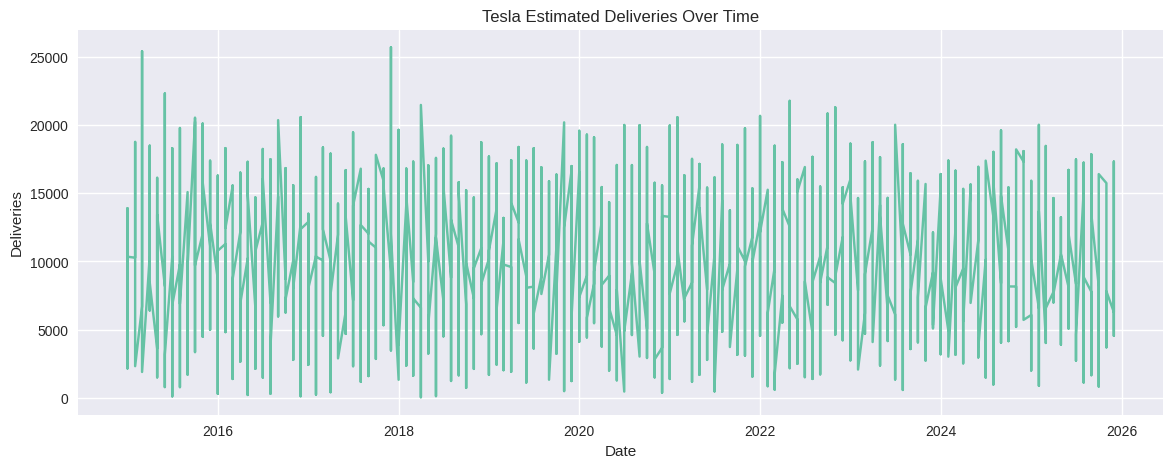

In [32]:
plt.figure(figsize=(14,5))

plt.plot(df['Date'], df['Estimated_Deliveries'])

plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.show()

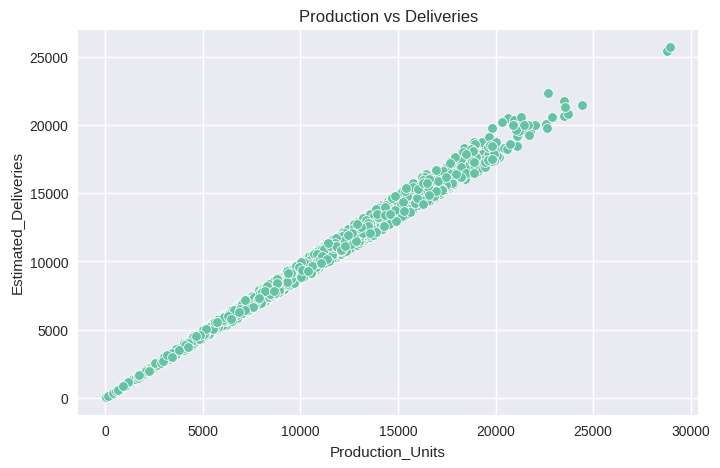

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)

plt.title("Production vs Deliveries")
plt.show()

In [34]:
df['Quarter'] = df['Date'].dt.quarter

df['Lag_1'] = df['Estimated_Deliveries'].shift(1)
df['Lag_2'] = df['Estimated_Deliveries'].shift(2)

df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)

df.dropna(inplace=True)

In [35]:
df = pd.get_dummies(
    df,
    columns=['Region','Model','Source_Type'],
    drop_first=True
)

In [36]:
X = df.drop(
    ['Estimated_Deliveries', 'Date'],
    axis=1
)

y = df['Estimated_Deliveries']

In [37]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [38]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [39]:
pred = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("MAE :", mean_absolute_error(y_test,pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred)))
print("R2 Score :", r2_score(y_test,pred))

MAE : 210.51577758789062
RMSE : 269.01190726434396
R2 Score : 0.9946323037147522


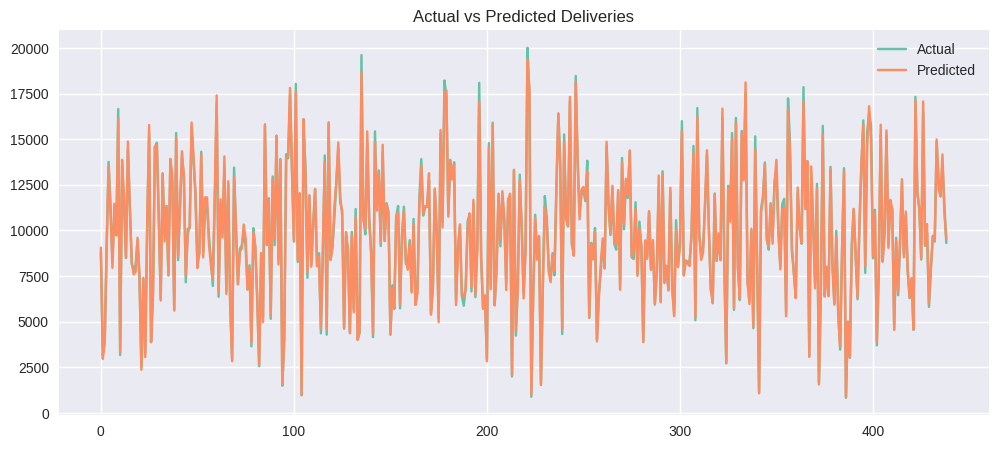

In [41]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values,label="Actual")
plt.plot(pred,label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Deliveries")

plt.show()

In [42]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                             Feature  Importance
2                   Production_Units    0.643945
6                     CO2_Saved_tons    0.231891
4               Battery_Capacity_kWh    0.052131
5                           Range_km    0.039002
11                    Rolling_Mean_3    0.009666
10                             Lag_2    0.004697
9                              Lag_1    0.003648
15                     Model_Model 3    0.002244
19  Source_Type_Interpolated (Month)    0.002118
0                               Year    0.001243


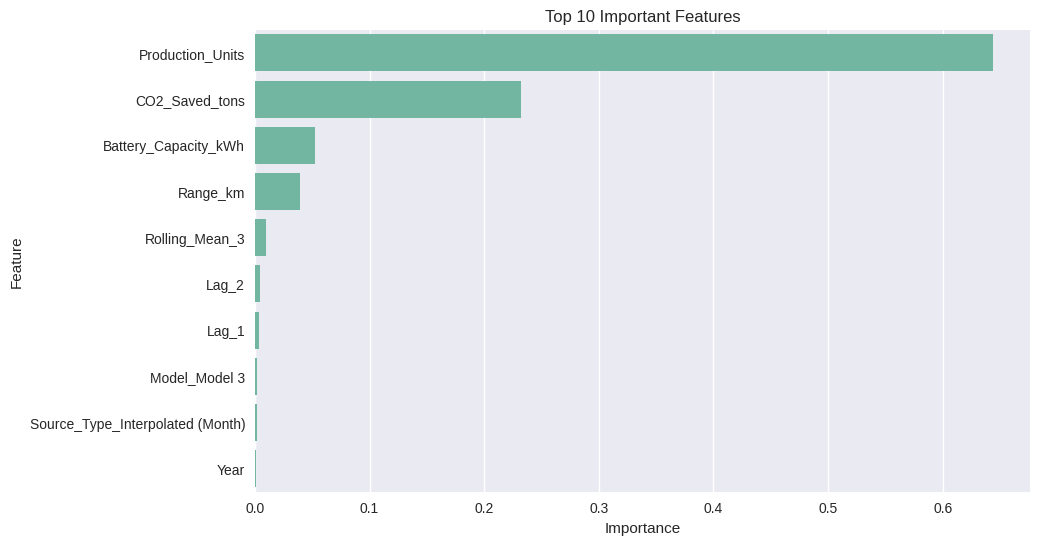

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [44]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2'
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [45]:
future_pred = model.predict(X.tail(12))

forecast_df = pd.DataFrame({
    'Actual': y.tail(12).values,
    'Predicted': future_pred
})

forecast_df

,Actual,Predicted
0,9164,9193.458008
1,9880,10352.715820
2,5817,5963.718262
3,7865,8036.691895
4,9701,9636.643555
5,9394,9445.104492
6,14840,14987.591797
7,12747,12254.409180
8,11972,11861.632812
9,13671,14167.981445


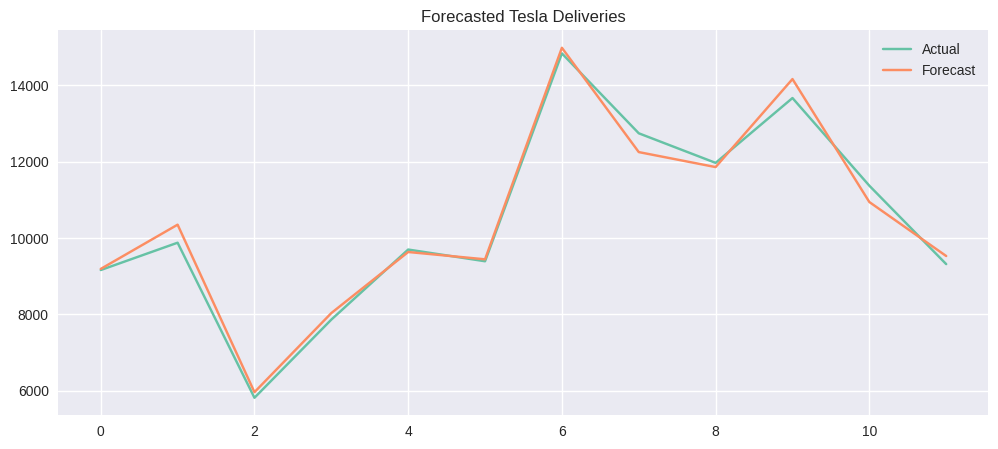

In [46]:
plt.figure(figsize=(12,5))

plt.plot(
    forecast_df['Actual'].values,
    label='Actual'
)

plt.plot(
    forecast_df['Predicted'].values,
    label='Forecast'
)

plt.title("Forecasted Tesla Deliveries")
plt.legend()

plt.show()